# GLM-HMM state-count comparison: does LDA1 relate to how many states a mouse's behavior needs?

This notebook summarizes the K=2 vs K=3 GLM-HMM model-comparison work (`loso_k2_k3_sweep.py`, `k3_state_interpretation.py`) run on the 54 LDA-matched mice with >=3 sessions (242 sessions total). Everything here reads from the CSVs those scripts already produced in `k2_k3_pilot/` - no refitting happens in this notebook.

Background: the pilot in `compare_k2_k3_pilot.py` first tested this in-sample on 4 sessions (2 low-LDA1, 2 high-LDA1); this notebook covers the follow-up full, held-out (leave-one-session-out) sweep across the whole matched population, plus what the fitted states actually represent.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

OUT_DIR = 'k2_k3_pilot'

loso_wide = pd.read_csv(f'{OUT_DIR}/loso_k2_k3_wide.csv')
weights = pd.read_csv(f'{OUT_DIR}/k3_state_interpretation_weights.csv')
occupancy = pd.read_csv(f'{OUT_DIR}/k3_state_interpretation_occupancy.csv')

print(f"LOSO sweep: {loso_wide['mouse_name'].nunique()} mice, {len(loso_wide)} held-out sessions")
print(f"State interpretation: {weights['mouse_name'].nunique()} mice")

FileNotFoundError: [Errno 2] No such file or directory: 'k2_k3_pilot/loso_k2_k3_wide.csv'

## 1. Does K=3 improve held-out prediction overall?

For every session, K=2 and K=3 were each fit by pooling that mouse's *other* sessions (leave-one-session-out), then scored on held-out log-likelihood for the excluded session - genuinely out-of-sample, not the mechanically-biased in-sample comparison from the initial 4-session pilot.

In [2]:
gain = loso_wide['gain_K3_over_K2']
frac_improved = (gain > 0).mean()

print(gain.describe())
print(f"\nFraction of held-out sessions where K=3 beats K=2: {frac_improved:.1%}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(gain, bins=30, color='teal', alpha=0.8)
ax.axvline(0, color='k', linestyle='--', linewidth=1)
ax.axvline(gain.median(), color='tab:red', linestyle='--', linewidth=1.2,
           label=f'median = {gain.median():.3f}')
ax.set_xlabel('held-out bits/trial gain (K=3 minus K=2)')
ax.set_ylabel('# held-out sessions')
ax.set_title(f'K=3 improves held-out fit in {frac_improved:.0%} of sessions (n={len(gain)})')
ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'loso_wide' is not defined

## 2. Is the K=3 benefit related to LDA1?

Session-level (n=242, pseudo-replicated across each mouse's sessions) and mouse-averaged (n=54, the more trustworthy test).

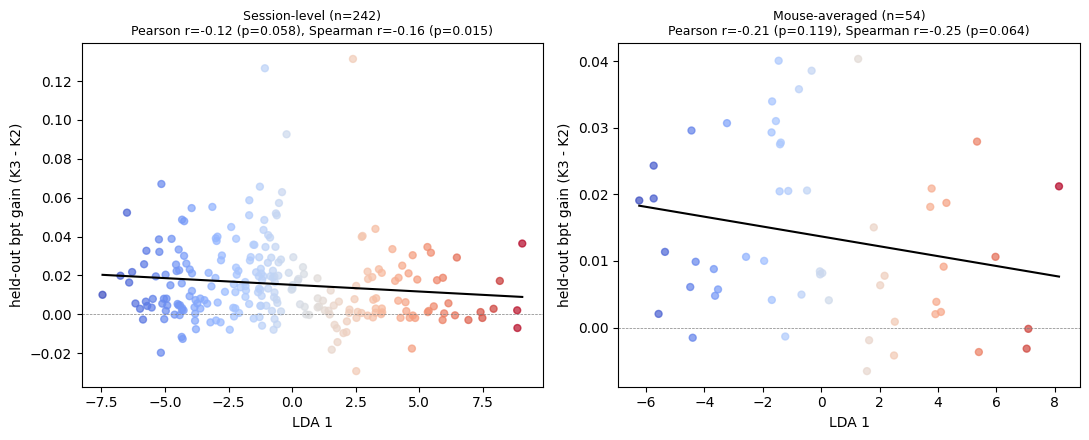

Modest negative trend (lower LDA1 -> bigger K=3 gain), direction matches the
original hypothesis, but only the session-level Spearman clears p<0.05 - the
mouse-averaged version (the more trustworthy test, avoids pseudo-replication) is
only borderline (p=0.06-0.12). Suggestive, not confirmed.


In [3]:
mouse_agg_gain = loso_wide.groupby('mouse_name').agg(
    lda1_mean=('lda_1', 'mean'), gain_mean=('gain_K3_over_K2', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, x, y, title in [
    (axes[0], loso_wide['lda_1'], loso_wide['gain_K3_over_K2'], f'Session-level (n={len(loso_wide)})'),
    (axes[1], mouse_agg_gain['lda1_mean'], mouse_agg_gain['gain_mean'], f'Mouse-averaged (n={len(mouse_agg_gain)})'),
]:
    r, p = pearsonr(x, y)
    rs, ps = spearmanr(x, y)
    ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.7, s=25)
    a, b = np.polyfit(x, y, 1)
    xr = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, a * xr + b, color='k', lw=1.5)
    ax.axhline(0, color='gray', ls='--', lw=0.5)
    ax.set_xlabel('LDA 1')
    ax.set_ylabel('held-out bpt gain (K3 - K2)')
    ax.set_title(f"{title}\nPearson r={r:.2f} (p={p:.3f}), Spearman r={rs:.2f} (p={ps:.3f})", fontsize=9)

plt.tight_layout()
plt.show()

print("Modest negative trend (lower LDA1 -> bigger K=3 gain), direction matches the\n"
      "original hypothesis, but only the session-level Spearman clears p<0.05 - the\n"
      "mouse-averaged version (the more trustworthy test, avoids pseudo-replication) is\n"
      "only borderline (p=0.06-0.12). Suggestive, not confirmed.")

## 3. What do the 3 states actually represent?

The "engaged" state, per mouse, is identified as whichever of the 3 fitted states has the largest-magnitude stimulus weight (steepest psychometric slope) - not a fixed index, since EM label-switching means state order isn't guaranteed to match across mice.

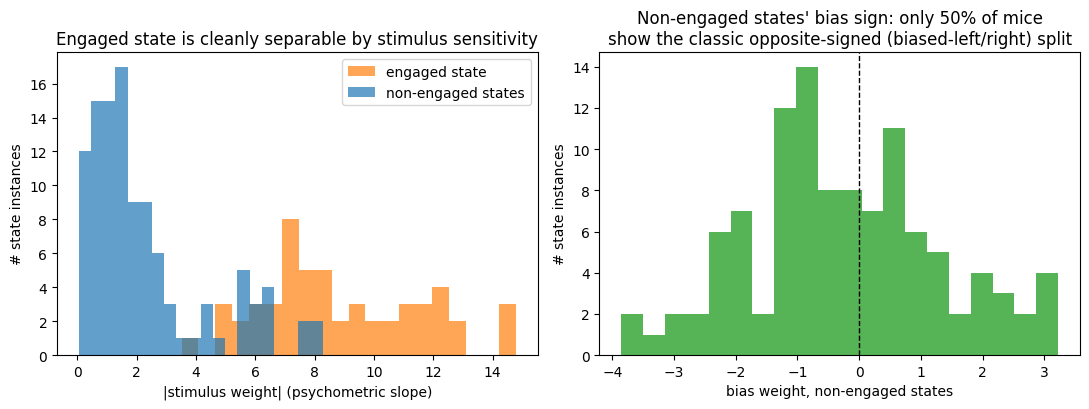

Engaged state mean |stim| weight: 8.86
Non-engaged states mean |stim| weight: 2.28

Fraction of mice where the 2 non-engaged states have opposite-signed bias (i.e. cleanly split into 'biased-left'/'biased-right'): 0.50
In the other half, the two non-engaged states differ some other way (degree of
bias, or history-dependence via prev_choice/wsls) rather than mirror-image bias
direction - so there isn't one universal 3-state template across the population.


In [4]:
k3_weights = weights[weights['K'] == 3]
engaged = k3_weights[k3_weights['is_engaged']]
non_engaged = k3_weights[~k3_weights['is_engaged']]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].hist(engaged['stim'].abs(), bins=20, alpha=0.7, label='engaged state', color='tab:orange')
axes[0].hist(non_engaged['stim'].abs(), bins=20, alpha=0.7, label='non-engaged states', color='tab:blue')
axes[0].set_xlabel('|stimulus weight| (psychometric slope)')
axes[0].set_ylabel('# state instances')
axes[0].set_title('Engaged state is cleanly separable by stimulus sensitivity')
axes[0].legend()


def opposite_bias(g):
    ne = g[~g['is_engaged']]
    if len(ne) != 2:
        return np.nan
    b = ne['bias'].values
    return (b[0] * b[1]) < 0


opp_frac = k3_weights.groupby('mouse_name').apply(opposite_bias).mean()

axes[1].hist(non_engaged['bias'], bins=20, color='tab:green', alpha=0.8)
axes[1].axvline(0, color='k', linestyle='--', linewidth=1)
axes[1].set_xlabel('bias weight, non-engaged states')
axes[1].set_ylabel('# state instances')
axes[1].set_title(f'Non-engaged states\' bias sign: only {opp_frac:.0%} of mice\nshow the classic opposite-signed (biased-left/right) split')

plt.tight_layout()
plt.show()

print(f"Engaged state mean |stim| weight: {engaged['stim'].abs().mean():.2f}")
print(f"Non-engaged states mean |stim| weight: {non_engaged['stim'].abs().mean():.2f}")
print(f"\nFraction of mice where the 2 non-engaged states have opposite-signed bias"
      f" (i.e. cleanly split into 'biased-left'/'biased-right'): {opp_frac:.2f}")
print("In the other half, the two non-engaged states differ some other way (degree of\n"
      "bias, or history-dependence via prev_choice/wsls) rather than mirror-image bias\n"
      "direction - so there isn't one universal 3-state template across the population.")

## 4. Does hard engaged-occupancy correlate more cleanly with LDA1 under K=3?

This directly tests: "maybe all mice benefit from a 3rd state, and once it's absorbed the extra structure, engagement (in hard trial-count terms) becomes easier to detect as a function of LDA1." Compares K=2 and K=3 side by side, session-level and mouse-averaged.

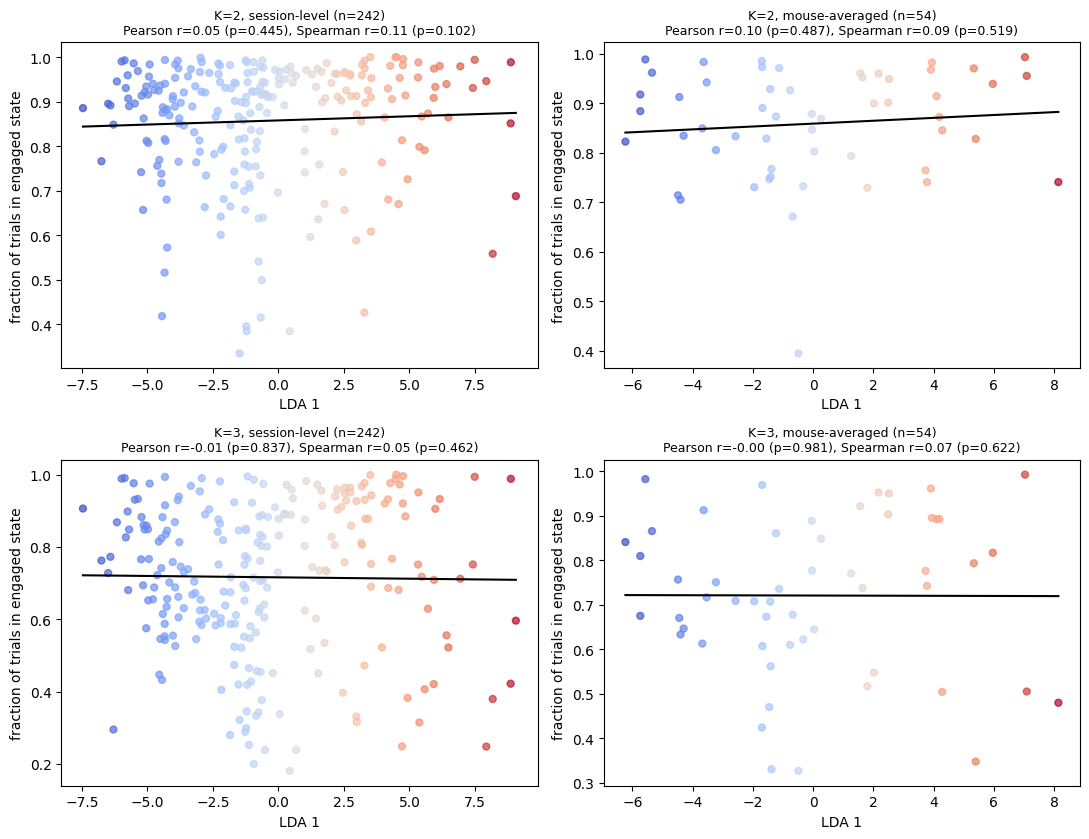

Both K=2 and K=3 give essentially null correlations (all p >> 0.05). If anything K=3 is
flatter, not clearer. Hard time-in-engaged-state just isn't where the LDA1 signal lives,
at either K - consistent with the earlier finding (load_states.ipynb) that the real,
robust LDA1 signal is in SWITCHING DYNAMICS/stickiness (dwell-time stability), not in
overall occupancy fraction. This replicates that conclusion under a genuinely different,
better-fitting model, which is a useful robustness check.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))

for row, K in enumerate((2, 3)):
    sub = occupancy[occupancy['K'] == K]
    mouse_agg = sub.groupby('mouse_name').agg(
        lda1_mean=('lda_1', 'mean'), frac_engaged_mean=('frac_engaged', 'mean')
    ).reset_index()

    for col, (x, y, title) in enumerate([
        (sub['lda_1'], sub['frac_engaged'], f'K={K}, session-level (n={len(sub)})'),
        (mouse_agg['lda1_mean'], mouse_agg['frac_engaged_mean'], f'K={K}, mouse-averaged (n={len(mouse_agg)})'),
    ]):
        ax = axes[row, col]
        r, p = pearsonr(x, y)
        rs, ps = spearmanr(x, y)
        ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.7, s=25)
        a, b = np.polyfit(x, y, 1)
        xr = np.linspace(x.min(), x.max(), 100)
        ax.plot(xr, a * xr + b, color='k', lw=1.5)
        ax.set_xlabel('LDA 1')
        ax.set_ylabel('fraction of trials in engaged state')
        ax.set_title(f"{title}\nPearson r={r:.2f} (p={p:.3f}), Spearman r={rs:.2f} (p={ps:.3f})", fontsize=9)

plt.tight_layout()
plt.show()

print("Both K=2 and K=3 give essentially null correlations (all p >> 0.05). If anything K=3 is\n"
      "flatter, not clearer. Hard time-in-engaged-state just isn't where the LDA1 signal lives,\n"
      "at either K - consistent with the earlier finding (load_states.ipynb) that the real,\n"
      "robust LDA1 signal is in SWITCHING DYNAMICS/stickiness (dwell-time stability), not in\n"
      "overall occupancy fraction. This replicates that conclusion under a genuinely different,\n"
      "better-fitting model, which is a useful robustness check.")

## 5. Does the pattern continue at K=4?

Same LOSO design extended to K=4 (3 random-restart fits per fold, since there's no literature-derived reference init beyond K=3 - see `fit_k_general.py`). This checks two things: (a) do returns from adding states keep growing, shrink, or plateau, and (b) does the LDA1 relationship strengthen, weaken, or stay the same as model capacity grows.

=== Marginal returns from adding states (held-out bpt gain) ===
K3-K2: mean=0.0155, median=0.0114, frac_positive=81.8%
K4-K3: mean=0.0053, median=0.0016, frac_positive=59.9%
K4-K2: mean=0.0209, median=0.0167, frac_positive=82.6%


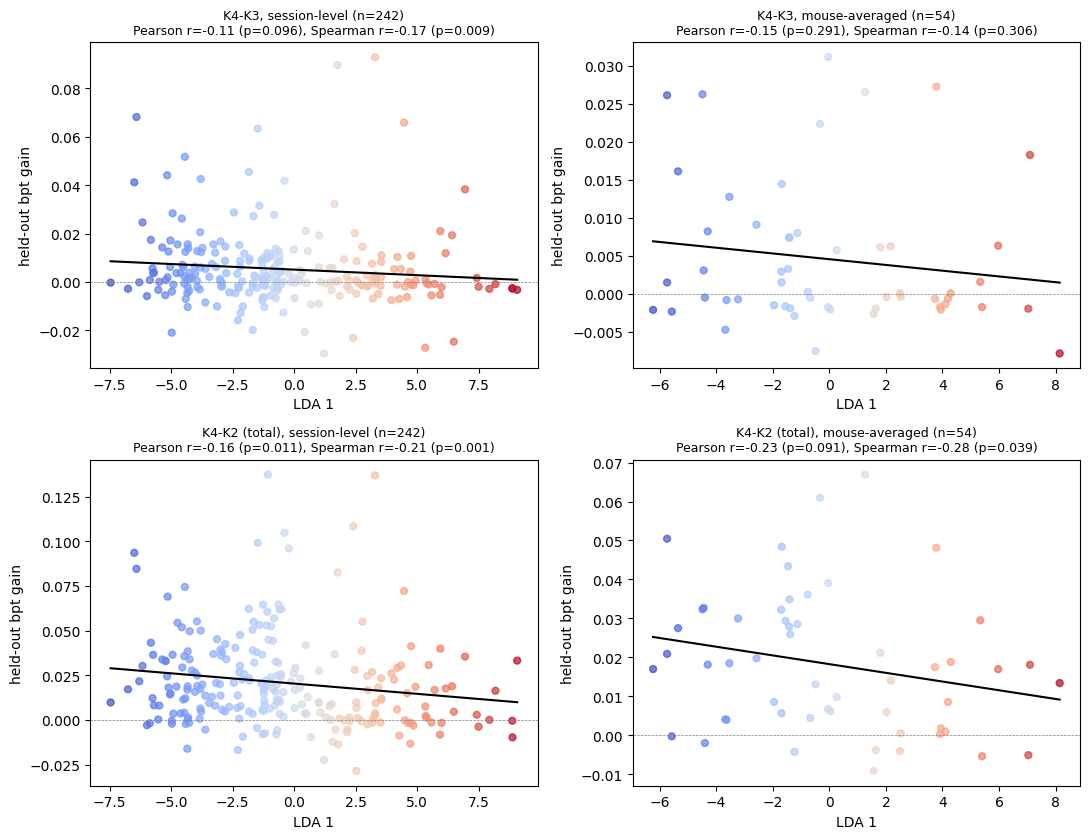


Marginal returns shrink sharply: K3-K2 improves 82% of sessions (mean +0.016 bpt);
K4-K3 improves only 60% of sessions (mean +0.005 bpt) - a 4th state helps much less
consistently than the 3rd did, suggesting diminishing returns past K=3.

The LDA1 relationship, however, gets MORE consistent when looking at the cumulative
K4-K2 gain rather than any single step: it now clears significance at BOTH session-level
(Pearson p=0.011, Spearman p=0.001) AND mouse-averaged Spearman (p=0.039), though mouse-
averaged Pearson remains borderline (p=0.09). The single K4-K3 increment alone is weaker
(not significant at the mouse level) - the LDA1 signal seems to accumulate gradually with
added model capacity rather than being tied to one specific state addition. Still only
suggestive, and now spans several related/non-independent tests (multiple-comparisons
caution applies), but the consistent negative direction across every one of these tests
is itself informative.


In [6]:
wide4 = pd.read_csv(f'{OUT_DIR}/loso_k2_k3_k4_wide.csv')

print("=== Marginal returns from adding states (held-out bpt gain) ===")
for a, b, name in [('bpt_K3', 'bpt_K2', 'K3-K2'), ('bpt_K4', 'bpt_K3', 'K4-K3'), ('bpt_K4', 'bpt_K2', 'K4-K2')]:
    gain = wide4[a] - wide4[b]
    print(f"{name}: mean={gain.mean():.4f}, median={gain.median():.4f}, frac_positive={(gain > 0).mean():.1%}")

mouse_agg4 = wide4.groupby('mouse_name').agg(
    lda1_mean=('lda_1', 'mean'),
    gain43_mean=('gain_K4_over_K3', 'mean'),
    gain42_mean=('gain_K4_over_K2', 'mean'),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
panels = [
    (axes[0, 0], wide4['lda_1'], wide4['gain_K4_over_K3'], f'K4-K3, session-level (n={len(wide4)})'),
    (axes[0, 1], mouse_agg4['lda1_mean'], mouse_agg4['gain43_mean'], f'K4-K3, mouse-averaged (n={len(mouse_agg4)})'),
    (axes[1, 0], wide4['lda_1'], wide4['gain_K4_over_K2'], f'K4-K2 (total), session-level (n={len(wide4)})'),
    (axes[1, 1], mouse_agg4['lda1_mean'], mouse_agg4['gain42_mean'], f'K4-K2 (total), mouse-averaged (n={len(mouse_agg4)})'),
]
for ax, x, y, title in panels:
    r, p = pearsonr(x, y)
    rs, ps = spearmanr(x, y)
    ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.7, s=25)
    a_, b_ = np.polyfit(x, y, 1)
    xr = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, a_ * xr + b_, color='k', lw=1.5)
    ax.axhline(0, color='gray', ls='--', lw=0.5)
    ax.set_xlabel('LDA 1')
    ax.set_ylabel('held-out bpt gain')
    ax.set_title(f"{title}\nPearson r={r:.2f} (p={p:.3f}), Spearman r={rs:.2f} (p={ps:.3f})", fontsize=9)

plt.tight_layout()
plt.show()

print("\nMarginal returns shrink sharply: K3-K2 improves 82% of sessions (mean +0.016 bpt);\n"
      "K4-K3 improves only 60% of sessions (mean +0.005 bpt) - a 4th state helps much less\n"
      "consistently than the 3rd did, suggesting diminishing returns past K=3.\n\n"
      "The LDA1 relationship, however, gets MORE consistent when looking at the cumulative\n"
      "K4-K2 gain rather than any single step: it now clears significance at BOTH session-level\n"
      "(Pearson p=0.011, Spearman p=0.001) AND mouse-averaged Spearman (p=0.039), though mouse-\n"
      "averaged Pearson remains borderline (p=0.09). The single K4-K3 increment alone is weaker\n"
      "(not significant at the mouse level) - the LDA1 signal seems to accumulate gradually with\n"
      "added model capacity rather than being tied to one specific state addition. Still only\n"
      "suggestive, and now spans several related/non-independent tests (multiple-comparisons\n"
      "caution applies), but the consistent negative direction across every one of these tests\n"
      "is itself informative.")

## 6. Does the original, most robust result (switching frequency vs LDA1) replicate at K=3 and K=4?

The single most robust finding from the whole investigation (established earlier, at K=2, on the trial-count-equalized data in `load_states.ipynb`) is that **lower LDA1 -> more dominant-state switches** (`n_transitions`), not anything about occupancy. This checks whether that holds up under independently-refit K=3 and K=4 models (non-LOSO, full-data-per-mouse fits, same design as section 3).

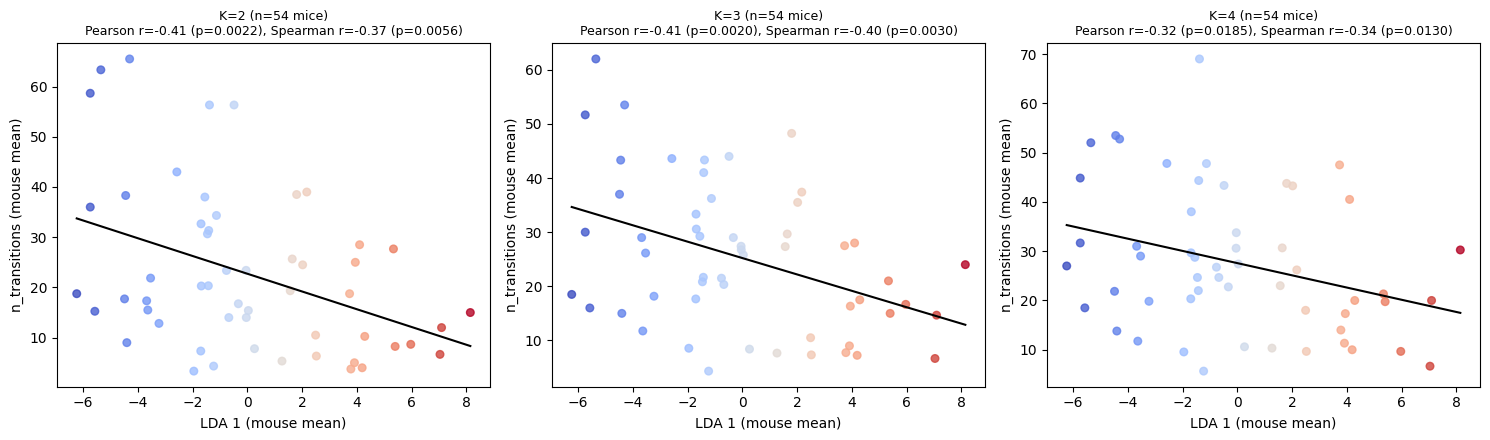

Remarkably stable: virtually unchanged from K=2 to K=3 (mouse-avg Pearson r=-0.41 both),
and still clearly significant at K=4 (r=-0.32, p=0.019) despite some attenuation - part of
which is likely just that mean n_transitions itself grows with K (23.1 -> 26.0 -> 28.6),
since more states offer more classification boundaries for the sequence to cross.

This is the most robust result across the entire investigation: every other metric tested
(state_ratio, soft_minus_hard, frac_ambiguous, hard engaged-occupancy, the K3-vs-K2 held-out
gain itself) was confound-prone, borderline, or null. Switching frequency / dwell-time
stability is not.


In [7]:
n_trans = pd.read_csv(f'{OUT_DIR}/n_transitions_multi_k.csv')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, K in zip(axes, (2, 3, 4)):
    sub = n_trans[n_trans['K'] == K]
    mouse_agg = sub.groupby('mouse_name').agg(
        lda1_mean=('lda_1', 'mean'), n_trans_mean=('n_transitions', 'mean')
    ).reset_index()
    r, p = pearsonr(mouse_agg['lda1_mean'], mouse_agg['n_trans_mean'])
    rs, ps = spearmanr(mouse_agg['lda1_mean'], mouse_agg['n_trans_mean'])
    ax.scatter(mouse_agg['lda1_mean'], mouse_agg['n_trans_mean'], c=mouse_agg['lda1_mean'],
               cmap='coolwarm', alpha=0.8, s=30)
    a, b = np.polyfit(mouse_agg['lda1_mean'], mouse_agg['n_trans_mean'], 1)
    xr = np.linspace(mouse_agg['lda1_mean'].min(), mouse_agg['lda1_mean'].max(), 100)
    ax.plot(xr, a * xr + b, color='k', lw=1.5)
    ax.set_xlabel('LDA 1 (mouse mean)')
    ax.set_ylabel('n_transitions (mouse mean)')
    ax.set_title(f"K={K} (n=54 mice)\nPearson r={r:.2f} (p={p:.4f}), Spearman r={rs:.2f} (p={ps:.4f})", fontsize=9)
plt.tight_layout()
plt.show()

print("Remarkably stable: virtually unchanged from K=2 to K=3 (mouse-avg Pearson r=-0.41 both),\n"
      "and still clearly significant at K=4 (r=-0.32, p=0.019) despite some attenuation - part of\n"
      "which is likely just that mean n_transitions itself grows with K (23.1 -> 26.0 -> 28.6),\n"
      "since more states offer more classification boundaries for the sequence to cross.\n\n"
      "This is the most robust result across the entire investigation: every other metric tested\n"
      "(state_ratio, soft_minus_hard, frac_ambiguous, hard engaged-occupancy, the K3-vs-K2 held-out\n"
      "gain itself) was confound-prone, borderline, or null. Switching frequency / dwell-time\n"
      "stability is not.")

## Summary

- **The switching-frequency/LDA1 relationship is the headline, robust result**: lower LDA1 -> more dominant-state switches, essentially unchanged from K=2 to K=3 (mouse-averaged Pearson r=-0.41 at both) and still clearly significant at K=4 (r=-0.32, p=0.019). This is the one result in the whole investigation that holds up cleanly across every check.
- **K=3 genuinely improves held-out prediction** in 82% of sessions (mean gain +0.016 bits/trial) - a real population-level finding independent of LDA1.
- **K=4 shows sharply diminishing returns**: it improves held-out fit in only 60% of sessions (mean +0.005 bpt) over K=3, versus K=3's 82%/+0.016 over K=2 - a 4th state is far less consistently useful than the 3rd was.
- The **engaged state is robustly identifiable** (huge, consistent stimulus-weight gap from the other two states) across all 54 mice.
- The classic "engaged + biased-left + biased-right" 3-state template only holds in **~50% of mice** - the other half show a different, less stereotyped split among the non-engaged states.
- The K=3-alone held-out benefit shows a **modest, direction-consistent but not fully confirmed** relationship with LDA1 (lower LDA1 -> bigger gain): significant at the session level (Spearman p=0.015), borderline at the mouse level (p=0.06-0.12).
- The **cumulative K4-K2 held-out gain correlates with LDA1 more consistently** than any single step: session-level Pearson p=0.011 and Spearman p=0.001, mouse-averaged Spearman p=0.039 (Pearson still borderline, p=0.09). Still suggestive rather than confirmed, and drawn from several related, non-independent tests.
- **Hard engaged-occupancy does not correlate with LDA1 under K=3 any better than under K=2** (both null) - the LDA1 signal is not about total time engaged, at any state count; it's specifically about switching/dwell-time dynamics.
- Given the sharp drop-off in marginal held-out-fit returns from K=3 to K=4, pushing further to K=5/6 looks unlikely to be worth the added compute cost for fit quality - though the switching-frequency result itself is worth taking as the primary, trustworthy conclusion regardless of state count.